# Clustering với k-Means

In [35]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 1. Dữ liệu giả định

**Giả sử có 3 tập**
1. Set 1: 50 điểm
1. Set 2: 75 điểm
1. Set 3: 100 điểm

In [36]:
np.random.seed(1)
x1,y1 = np.random.normal(loc=2,scale=1,size=50), np.random.normal(loc=5,scale=1,size=50)
x2,y2 = np.random.normal(loc=5,scale=1,size=75), np.random.normal(loc=1,scale=1,size=75)
x3,y3 = np.random.normal(loc=8,scale=1,size=100), np.random.normal(loc=7,scale=1,size=100)

**=== Hiển thị 3 tập để kiểm tra ===**

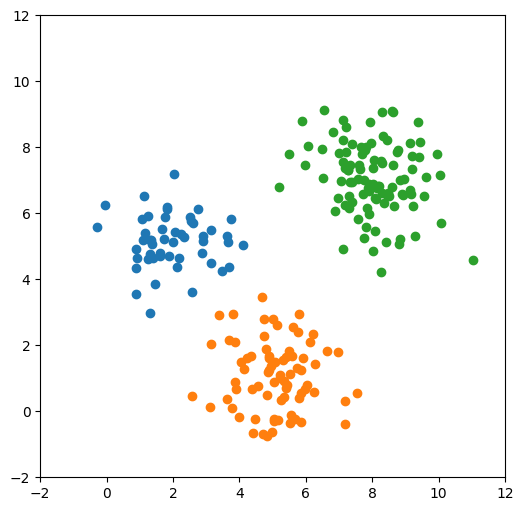

In [37]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(x1, y1)
plt.scatter(x2, y2)
plt.scatter(x3, y3)
plt.show()

### Ghép nối dữ liệu lại thành 1 tập chưa được clustered

In [38]:
dat1 = np.stack([x1, y1]).T

In [39]:
dat2 = np.stack([x2,y2]).T
dat3 = np.stack([x3,y3]).T
dat = np.concatenate([dat1, dat2, dat3], axis=0)

**=== Tập dữ liệu giả định có 225 dòng, 2 cột (x,y) ===**

In [40]:
print(dat.shape)


(225, 2)


### Sắp ngẫu nhiên các dòng

In [41]:
np.random.seed(2)
np.random.shuffle(dat)

### Kiểm tra lại với biểu đồ scatter

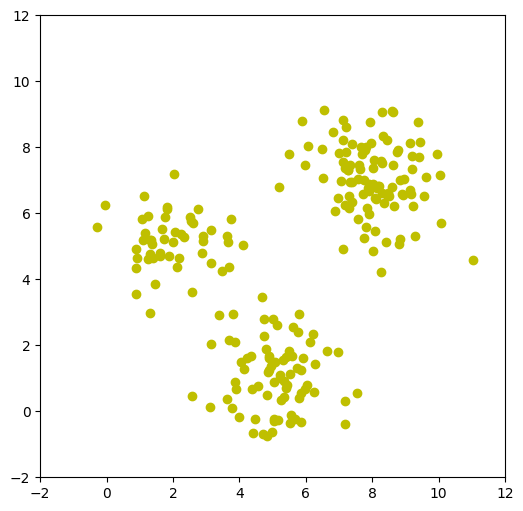

In [42]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.show()

## 2. Thực hiện phân cụm

### 2.1. Giả sử K=3 và tìm 3 điểm ban đầu ngẫu nhiên

In [43]:
K = 3

In [44]:
np.random.seed(30)
init_indices = np.random.choice(len(dat), K, replace=False)
print(init_indices)

[  8 180 170]


**Gán các trung tâm cho 3 điểm này**

In [45]:
centroids = dat[init_indices]
print(centroids)

[[5.338 0.438]
 [2.617 5.698]
 [4.9   1.243]]


**=== Vẽ K điểm centroids ban đầu lên biểu đồ ===**

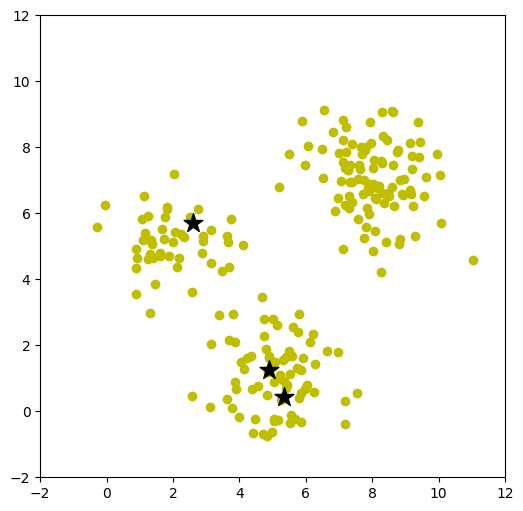

In [46]:
fig = plt.figure(figsize=(6, 6))
plt.xlim([-2, 12])
plt.ylim([-2, 12])

plt.scatter(dat[:, 0], dat[:, 1], color='y')
plt.scatter(centroids[:, 0], centroids[:, 1], color='k', marker='*', s=200)

plt.show()

### 2.2. Tiến hành gom cụm lần 1

**=== Khởi tạo K danh sách rỗng (để chứa các điểm của mỗi cluster) ===**

In [47]:
cList = [[] for _ in range(K)]
print(cList)

[[], [], []]


**=== Với mỗi sample, tìm xem nó gần điểm centroid nào nhất ===**

In [48]:
for sample in dat:
    distances = np.sqrt(np.sum((sample - centroids)**2, axis=1))
    cluster_idx = np.argmin(distances)
    cList[cluster_idx].append(sample)

In [49]:
# Thử kiểm tra lại mỗi list
for i in range(K): print(len(cList[i]))

29
138
58


**=== Thử lấy cluster đầu tiên ra và đánh giá ===**

In [50]:
np.stack(cList[0]).shape

(29, 2)

In [51]:
# Tọa độ của điểm centroid mới
np.stack(cList[0]).mean(axis=0)

array([5.584, 0.19 ])

**=== Tính lại các điểm centroids ===**

In [52]:
centroids = np.array([np.stack(cList[i]).mean(axis=0) for i in range(K)])
print(centroids)

[[5.584 0.19 ]
 [5.764 6.535]
 [5.594 2.377]]


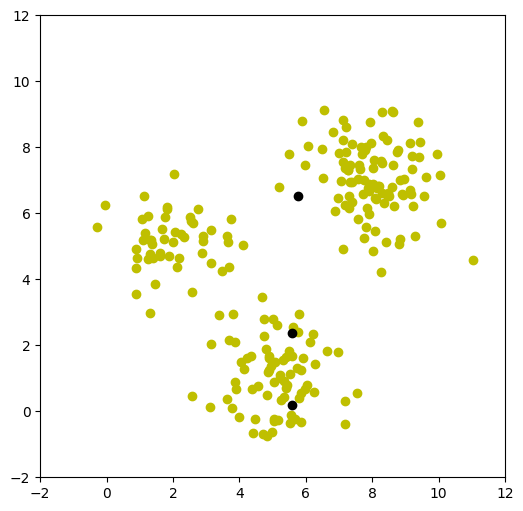

In [53]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.scatter(centroids[:,0], centroids[:,1], color='k')

plt.show()

### 2.3. Tiến hành gom cụm lần 2

**=== Tiếp tục khởi tạo K list rỗng để chứa các cluster mới ===**

In [54]:
cList = [[] for _ in range(K)]
for sample in dat:
    kq = np.sum((sample - centroids)**2, axis=1)
    min_d_idx = np.argmin(kq)
    cList[min_d_idx].append(sample)

# Tính giá trị của các centroids mới
centroids = [np.stack(cList[i]).mean(axis=0) for i in range(K)]
centroids = np.stack(centroids)
print(centroids)

[[5.099 0.36 ]
 [6.268 6.612]
 [4.451 2.574]]


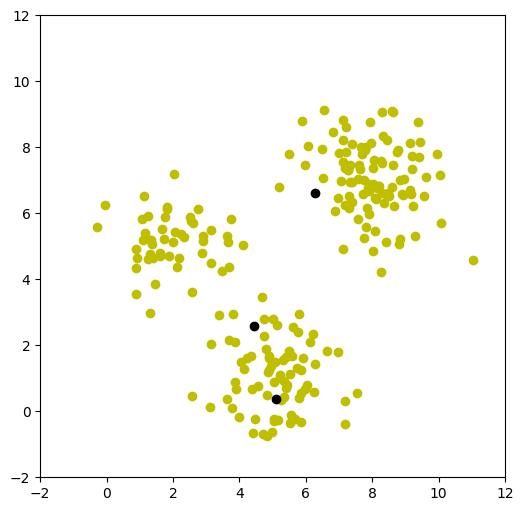

In [55]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.scatter(centroids[:,0], centroids[:,1], color='k')

plt.show()

### 2.4. Tiến hành gom cụm lần 3

**=== Tiếp tục khởi tạo K list rỗng để chứa các cluster mới ===**

In [56]:
cList = [[] for _ in range(K)]
for sample in dat:
    kq = np.sum((sample - centroids)**2, axis=1)
    min_d_idx = np.argmin(kq)
    cList[min_d_idx].append(sample)

centroids = [np.stack(cList[i]).mean(axis=0) for i in range(K)]
centroids = np.stack(centroids)
print(centroids)

[[5.225 0.569]
 [7.744 7.031]
 [2.898 4.079]]


**==> Nhận xét: các giá trị trung tâm gần như ít thay đổi**

In [59]:
# Lấy ra các cluster
c1 = np.stack(cList[0])
c2 = np.stack(cList[1])
c3 = np.stack(cList[2])



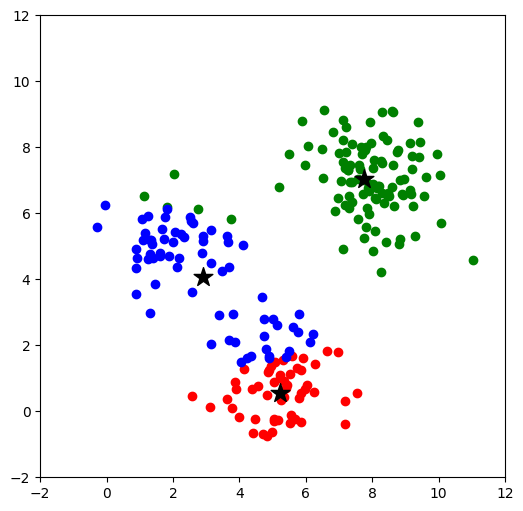

In [60]:
# Hiển thị 3 cluster lên biểu đồ
fig = plt.figure(figsize=(6, 6))
plt.xlim([-2, 12])
plt.ylim([-2, 12])

colors = ['r', 'g', 'b']
for i in range(K):
    cluster_data = np.stack(cList[i])
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], color=colors[i])

plt.scatter(centroids[:, 0], centroids[:, 1], color='k', marker='*', s=200)

plt.show()